In [28]:
import pandas as pd
import pandas as pd
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [29]:
df=pd.read_csv('dataset_phishing.csv')

In [30]:
df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [31]:
MODEL_B_FEATURES = [
    # URL length / structure
    "length_url",
    "length_hostname",
    "length_words_raw",
    
    # Character counts
    "nb_dots",
    "nb_hyphens",
    "nb_at",
    "nb_qm",
    "nb_and",
    "nb_eq",
    "nb_underscore",
    "nb_tilde",
    "nb_percent",
    "nb_slash",
    "nb_colon",
    "nb_comma",
    "nb_semicolumn",
    "nb_dollar",
    "nb_dslash",

    # URL digit characteristics
    "ratio_digits_url",
    "ratio_digits_host",

    # Host/domain characteristics
    "ip",
    "nb_www",
    "nb_subdomains",
    "shortest_word_host",
    "longest_word_host",
    "avg_word_host",

    # Path characteristics
    "shortest_word_path",
    "longest_word_path",
    "avg_word_path",

    # URL word characteristics
    "shortest_words_raw",
    "longest_words_raw",
    "avg_words_raw",
    "char_repeat",

    # Suspicious URL characteristics
    "prefix_suffix",
    "tld_in_subdomain",
    "abnormal_subdomain",
    "phish_hints",

    # URL services / structure
    "https_token",
    "tld_in_path",
    "path_extension",
]

In [32]:
import re
import ipaddress
from urllib.parse import urlparse


# ---------------------------------------------------------
# Features used by Model B
# ---------------------------------------------------------

MODEL_B_FEATURES = [
    "length_url",
    "length_hostname",
    "length_words_raw",

    "nb_dots",
    "nb_hyphens",
    "nb_at",
    "nb_qm",
    "nb_and",
    "nb_eq",
    "nb_underscore",
    "nb_tilde",
    "nb_percent",
    "nb_slash",
    "nb_colon",
    "nb_comma",
    "nb_semicolumn",
    "nb_dollar",
    "nb_dslash",

    "ratio_digits_url",
    "ratio_digits_host",

    "ip",
    "nb_www",
    "nb_subdomains",
    "shortest_word_host",
    "longest_word_host",
    "avg_word_host",

    "shortest_word_path",
    "longest_word_path",
    "avg_word_path",

    "shortest_words_raw",
    "longest_words_raw",
    "avg_words_raw",
    "char_repeat",

    "prefix_suffix",
    "tld_in_subdomain",
    "abnormal_subdomain",
    "phish_hints",

    "https_token",
    "tld_in_path",
    "path_extension",
]


# ---------------------------------------------------------
# Common TLDs
# ---------------------------------------------------------

COMMON_TLDS = {
    "com", "org", "net", "edu", "gov", "mil",
    "co", "uk", "in", "us", "ca", "au",
    "de", "fr", "jp", "cn", "ru", "ch",
    "it", "nl", "info", "biz", "xyz",
    "online", "site", "top", "club",
    "live", "shop", "store", "tech",
    "app", "dev", "me", "io"
}


# ---------------------------------------------------------
# Phishing-related keywords
# ---------------------------------------------------------

PHISHING_WORDS = [
    "login",
    "log-in",
    "signin",
    "sign-in",
    "account",
    "verify",
    "verification",
    "secure",
    "security",
    "update",
    "confirm",
    "confirmation",
    "password",
    "passwd",
    "bank",
    "banking",
    "payment",
    "wallet",
    "credential",
    "authenticate",
    "authentication",
    "recover",
    "unlock",
    "suspend",
    "validate",
]


# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------

def get_words(text):
    """
    Extract alphanumeric words from a string.
    """

    if not text:
        return []

    return re.findall(r"[A-Za-z0-9]+", text)


def safe_average(values):
    """
    Return average of list.
    """

    if not values:
        return 0

    return sum(values) / len(values)


def is_ip_address(hostname):
    """
    Check whether hostname is an IPv4 or IPv6 address.
    """

    if not hostname:
        return 0

    try:
        ipaddress.ip_address(hostname)
        return 1
    except ValueError:
        return 0


def count_character_repetition(text):
    """
    Estimate repeated consecutive characters.

    Example:
        aaa -> 2 repetitions
        abc -> 0
        xxxx -> 3
    """

    if not text:
        return 0

    repetitions = 0

    for i in range(1, len(text)):
        if text[i] == text[i - 1]:
            repetitions += 1

    return repetitions


def count_phishing_hints(url):
    """
    Count phishing-related words appearing in the URL.
    """

    url_lower = url.lower()

    count = 0

    for word in PHISHING_WORDS:
        if word in url_lower:
            count += 1

    return count


def has_tld_in_path(path):
    """
    Check whether a common TLD appears inside the URL path.
    """

    if not path:
        return 0

    path_lower = path.lower()

    for tld in COMMON_TLDS:

        # Look for .com, .org, .net etc.
        if "." + tld in path_lower:
            return 1

    return 0


def has_tld_in_subdomain(hostname):
    """
    Check whether a TLD appears in a subdomain.

    Example:

        login.com.example.com

    Here '.com' occurs before the actual domain.
    """

    if not hostname:
        return 0

    parts = hostname.lower().split(".")

    if len(parts) < 3:
        return 0

    # Everything except final two components
    subdomain_parts = parts[:-2]

    for part in subdomain_parts:

        if part in COMMON_TLDS:
            return 1

    return 0


def calculate_subdomains(hostname):
    """
    Approximate number of subdomains.

    Example:

        login.mail.example.com

    -> 2 subdomains
    """

    if not hostname:
        return 0

    parts = hostname.split(".")

    if len(parts) <= 2:
        return 0

    return len(parts) - 2


# ---------------------------------------------------------
# Main feature extractor
# ---------------------------------------------------------

def extract_url_features(url):

    # -----------------------------------------------------
    # Basic cleaning
    # -----------------------------------------------------

    url = url.strip()

    # urlparse works better when scheme exists
    if not re.match(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", url):
        parsed = urlparse("http://" + url)
    else:
        parsed = urlparse(url)

    hostname = parsed.hostname or ""
    path = parsed.path or ""
    query = parsed.query or ""

    url_lower = url.lower()

    # -----------------------------------------------------
    # WORD EXTRACTION
    # -----------------------------------------------------

    raw_words = get_words(url)
    host_words = get_words(hostname)
    path_words = get_words(path)

    raw_word_lengths = [len(word) for word in raw_words]
    host_word_lengths = [len(word) for word in host_words]
    path_word_lengths = [len(word) for word in path_words]

    # -----------------------------------------------------
    # URL LENGTH
    # -----------------------------------------------------

    length_url = len(url)

    length_hostname = len(hostname)

    length_words_raw = len(raw_words)

    # -----------------------------------------------------
    # CHARACTER COUNTS
    # -----------------------------------------------------

    nb_dots = url.count(".")

    nb_hyphens = url.count("-")

    nb_at = url.count("@")

    nb_qm = url.count("?")

    nb_and = url.count("&")

    nb_eq = url.count("=")

    nb_underscore = url.count("_")

    nb_tilde = url.count("~")

    nb_percent = url.count("%")

    nb_slash = url.count("/")

    nb_colon = url.count(":")

    nb_comma = url.count(",")

    nb_semicolumn = url.count(";")

    nb_dollar = url.count("$")

    nb_dslash = url.count("//")

    # -----------------------------------------------------
    # DIGIT RATIOS
    # -----------------------------------------------------

    digit_count_url = sum(char.isdigit() for char in url)

    digit_count_host = sum(char.isdigit() for char in hostname)

    if length_url > 0:
        ratio_digits_url = digit_count_url / length_url
    else:
        ratio_digits_url = 0

    if len(hostname) > 0:
        ratio_digits_host = digit_count_host / len(hostname)
    else:
        ratio_digits_host = 0

    # -----------------------------------------------------
    # IP ADDRESS
    # -----------------------------------------------------

    ip = is_ip_address(hostname)

    # -----------------------------------------------------
    # WWW
    # -----------------------------------------------------

    nb_www = url_lower.count("www")

    # -----------------------------------------------------
    # SUBDOMAINS
    # -----------------------------------------------------

    nb_subdomains = calculate_subdomains(hostname)

    # -----------------------------------------------------
    # HOST WORD STATISTICS
    # -----------------------------------------------------

    if host_word_lengths:

        shortest_word_host = min(host_word_lengths)

        longest_word_host = max(host_word_lengths)

        avg_word_host = safe_average(host_word_lengths)

    else:

        shortest_word_host = 0

        longest_word_host = 0

        avg_word_host = 0

    # -----------------------------------------------------
    # PATH WORD STATISTICS
    # -----------------------------------------------------

    if path_word_lengths:

        shortest_word_path = min(path_word_lengths)

        longest_word_path = max(path_word_lengths)

        avg_word_path = safe_average(path_word_lengths)

    else:

        shortest_word_path = 0

        longest_word_path = 0

        avg_word_path = 0

    # -----------------------------------------------------
    # RAW URL WORD STATISTICS
    # -----------------------------------------------------

    if raw_word_lengths:

        shortest_words_raw = min(raw_word_lengths)

        longest_words_raw = max(raw_word_lengths)

        avg_words_raw = safe_average(raw_word_lengths)

    else:

        shortest_words_raw = 0

        longest_words_raw = 0

        avg_words_raw = 0

    # -----------------------------------------------------
    # CHARACTER REPETITION
    # -----------------------------------------------------

    char_repeat = count_character_repetition(url)

    # -----------------------------------------------------
    # PREFIX / SUFFIX
    # -----------------------------------------------------

    prefix_suffix = 1 if "-" in hostname else 0

    # -----------------------------------------------------
    # TLD IN SUBDOMAIN
    # -----------------------------------------------------

    tld_in_subdomain = has_tld_in_subdomain(hostname)

    # -----------------------------------------------------
    # ABNORMAL SUBDOMAIN
    # -----------------------------------------------------

    # Approximation:
    # excessive subdomain depth can indicate suspicious URLs

    abnormal_subdomain = 1 if nb_subdomains > 3 else 0

    # -----------------------------------------------------
    # PHISHING HINTS
    # -----------------------------------------------------

    phish_hints = count_phishing_hints(url)

    # -----------------------------------------------------
    # HTTPS TOKEN
    # -----------------------------------------------------

    # Detect "https" appearing somewhere in the URL
    # rather than only checking the scheme.

    https_token = 1 if "https" in url_lower else 0

    # -----------------------------------------------------
    # TLD IN PATH
    # -----------------------------------------------------

    tld_in_path = has_tld_in_path(path)

    # -----------------------------------------------------
    # PATH EXTENSION
    # -----------------------------------------------------

    path_extension = 0

    if path:

        last_part = path.split("/")[-1]

        if "." in last_part:

            extension = last_part.split(".")[-1]

            if extension and len(extension) <= 5:

                path_extension = 1

    # -----------------------------------------------------
    # CREATE FEATURE DICTIONARY
    # -----------------------------------------------------

    features = {

        "length_url": length_url,
        "length_hostname": length_hostname,
        "length_words_raw": length_words_raw,

        "nb_dots": nb_dots,
        "nb_hyphens": nb_hyphens,
        "nb_at": nb_at,
        "nb_qm": nb_qm,
        "nb_and": nb_and,
        "nb_eq": nb_eq,
        "nb_underscore": nb_underscore,
        "nb_tilde": nb_tilde,
        "nb_percent": nb_percent,
        "nb_slash": nb_slash,
        "nb_colon": nb_colon,
        "nb_comma": nb_comma,
        "nb_semicolumn": nb_semicolumn,
        "nb_dollar": nb_dollar,
        "nb_dslash": nb_dslash,

        "ratio_digits_url": ratio_digits_url,
        "ratio_digits_host": ratio_digits_host,

        "ip": ip,
        "nb_www": nb_www,
        "nb_subdomains": nb_subdomains,

        "shortest_word_host": shortest_word_host,
        "longest_word_host": longest_word_host,
        "avg_word_host": avg_word_host,

        "shortest_word_path": shortest_word_path,
        "longest_word_path": longest_word_path,
        "avg_word_path": avg_word_path,

        "shortest_words_raw": shortest_words_raw,
        "longest_words_raw": longest_words_raw,
        "avg_words_raw": avg_words_raw,

        "char_repeat": char_repeat,

        "prefix_suffix": prefix_suffix,
        "tld_in_subdomain": tld_in_subdomain,
        "abnormal_subdomain": abnormal_subdomain,
        "phish_hints": phish_hints,

        "https_token": https_token,
        "tld_in_path": tld_in_path,
        "path_extension": path_extension,
    }

    return features

In [33]:
feature_rows = []

for url in df["url"]:

    features = extract_url_features(url)

    feature_rows.append(features)


X = pd.DataFrame(feature_rows)

# Force exact feature order
X = X[MODEL_B_FEATURES]

In [34]:
print("X shape:", X.shape)

X shape: (11430, 40)


In [35]:
y = df["status"].map({
    "legitimate": 0,
    "phishing": 1
})

print(y.value_counts())

status
0    5715
1    5715
Name: count, dtype: int64


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [38]:
model.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
y_pred = model.predict(X_test)

In [40]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Decision Tree Results")
print("----------------------------")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Decision Tree Results
----------------------------
Accuracy : 0.8504
Precision: 0.8391
Recall   : 0.8670
F1 Score : 0.8528


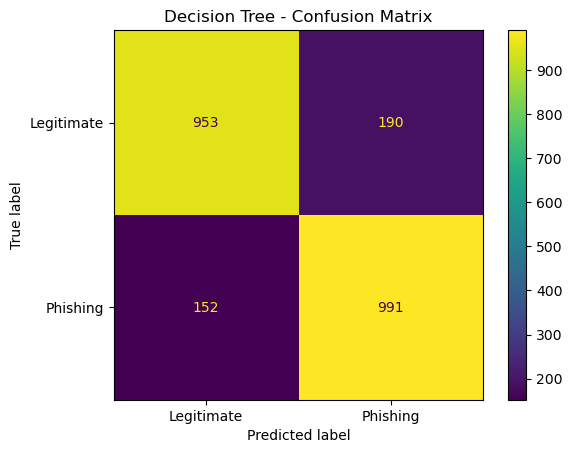

In [41]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Legitimate",
        "Phishing"
    ]
)

disp.plot()

import matplotlib.pyplot as plt

plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [42]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.8848425196850394
Testing Accuracy : 0.8503937007874016


In [43]:
os.makedirs("models/decisiontree", exist_ok=True)

joblib.dump(
    model,
    "models/decisiontree/decision_tree_model_b.pkl"
)

joblib.dump(
    MODEL_B_FEATURES,
    "models/decisiontree/decision_tree_features.pkl"
)

print("Decision Tree saved!")

Decision Tree saved!
